# Gentili Filippo 899906

## Librerie utilizzate: 

In [28]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import scipy.stats as stats
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error
import seaborn as sns
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
import statsmodels.api as sm
import ffn
import zipfile
from io import StringIO
from sklearn.exceptions import ConvergenceWarning
import requests
import io
import getFamaFrenchFactors as gff

## Download dati storici tramite yfinance

In [3]:
start_date = pd.Timestamp('2014-05-31')
end_date = pd.Timestamp('2024-05-31')

tickers = ['TSLA', 'GM', 'LMT', 'BA', 'GIS', 'HRL']
data = yf.download(tickers = tickers, start=start_date, end=end_date)

print(type(data))
print(data.head())
print(data.columns.to_list())
print(data.columns.levels)



YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  6 of 6 completed

<class 'pandas.core.frame.DataFrame'>
Price            Close                                               \
Ticker              BA        GIS         GM        HRL         LMT   
Date                                                                  
2014-06-02  117.460350  37.772373  26.346659  19.246975  121.854866   
2014-06-03  117.443077  37.868687  26.648966  19.325068  121.691513   
2014-06-04  116.967697  38.219517  27.601265  19.360216  122.159317   
2014-06-05  118.255547  38.068176  27.412308  19.309452  123.503235   
2014-06-06  119.491478  38.116333  27.854324  19.239161  124.126961   

Price                        High                                   ...  \
Ticker           TSLA          BA        GIS         GM        HRL  ...   
Date                                                                ...   
2014-06-02  13.646667  117.572715  37.875559  26.376891  19.278213  ...   
2014-06-03  13.662667  118.004876  37.882445  26.973953  19.352401  ...   
2014-06-04  13.599

## Grafico performance dei titoli

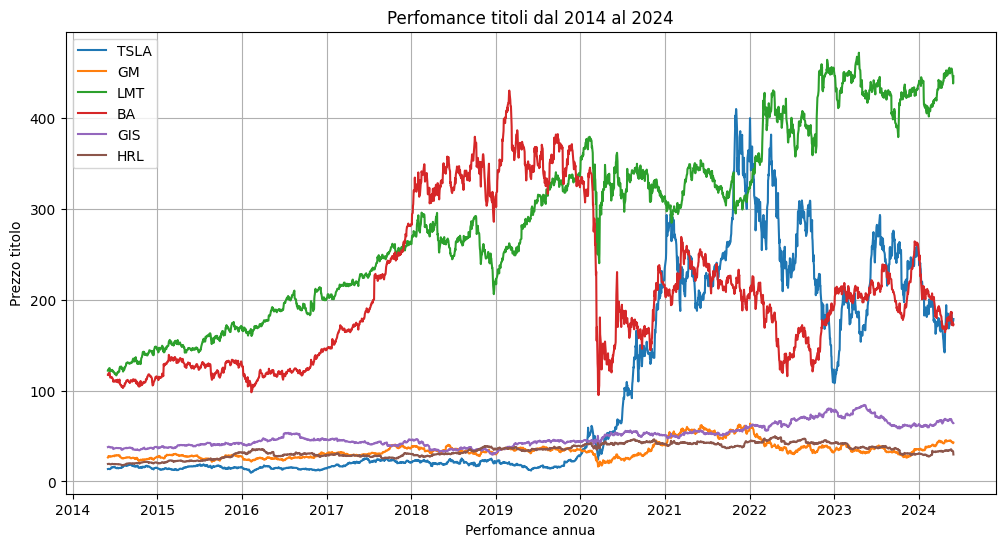

In [4]:
prices = data['Close']
plt.figure(figsize=(12, 6))

for ticker in tickers:
    plt.plot(prices.index, prices[ticker], label=ticker)

plt.title('Perfomance titoli dal 2014 al 2024')
plt.xlabel('Perfomance annua')
plt.ylabel('Prezzo titolo')
plt.grid(True)
plt.legend()
plt.show()

## Rendimento cumulato e composto annuale per titolo

In [5]:
for ticker in tickers:
    ticker_prices = data['Close'][ticker].dropna()

    cumulative_return = (ticker_prices.iloc[-1] / ticker_prices.iloc[0]) - 1
    start_price = ticker_prices.iloc[0]
    end_price = ticker_prices.iloc[-1]
    num_years = (ticker_prices.index[-1] - ticker_prices.index[0]).days / 365
    cagr = (end_price / start_price) ** (1 / num_years) - 1

    print(f'{ticker}')
    print(f'  Rendimento Cumulato: {cumulative_return:.2%}')
    print(f'  Rendimento Composto Annuo (CAGR): {cagr:.2%}\n')


TSLA
  Rendimento Cumulato: 1210.14%
  Rendimento Composto Annuo (CAGR): 29.34%

GM
  Rendimento Cumulato: 62.62%
  Rendimento Composto Annuo (CAGR): 4.98%

LMT
  Rendimento Cumulato: 266.08%
  Rendimento Composto Annuo (CAGR): 13.86%

BA
  Rendimento Cumulato: 47.07%
  Rendimento Composto Annuo (CAGR): 3.93%

GIS
  Rendimento Cumulato: 69.83%
  Rendimento Composto Annuo (CAGR): 5.44%

HRL
  Rendimento Cumulato: 54.07%
  Rendimento Composto Annuo (CAGR): 4.42%



## Grafico rendimento cumulato

TSLA: 1210.14%
GM: 62.62%
LMT: 266.08%
BA: 47.07%
GIS: 69.83%
HRL: 54.07%


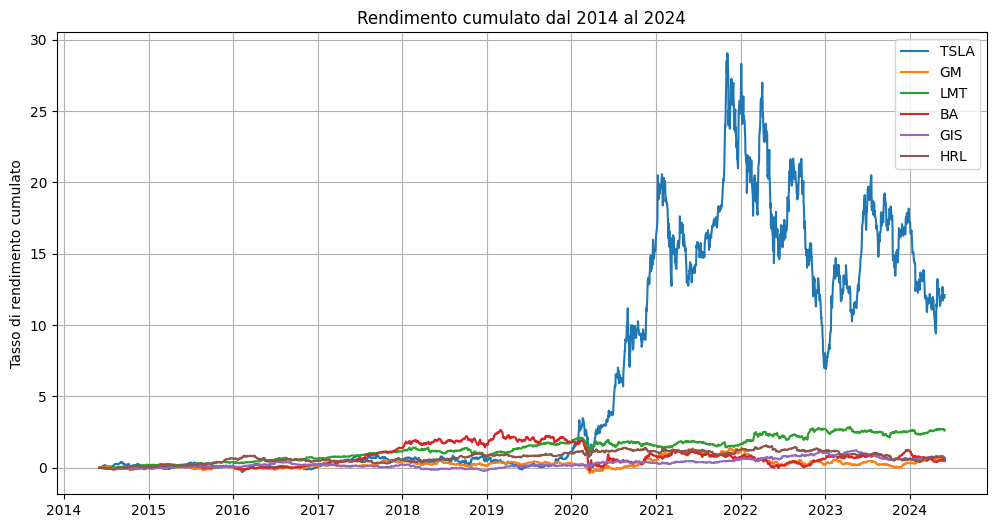

In [6]:
plt.figure(figsize=(12, 6))
for ticker in tickers:
    prices = data.Close[ticker].dropna()
    cum_ret = prices / prices.iloc[0] - 1
    print(f"{ticker}: {cum_ret.iloc[-1]:.2%}")
    plt.plot(cum_ret, label=ticker)

plt.title('Rendimento cumulato dal 2014 al 2024')
plt.ylabel("Tasso di rendimento cumulato")
plt.grid(True)
plt.legend()
plt.show()

## Grafico CAGR

TSLA: 29.34%
GM: 4.98%
LMT: 13.86%
BA: 3.93%
GIS: 5.44%
HRL: 4.42%


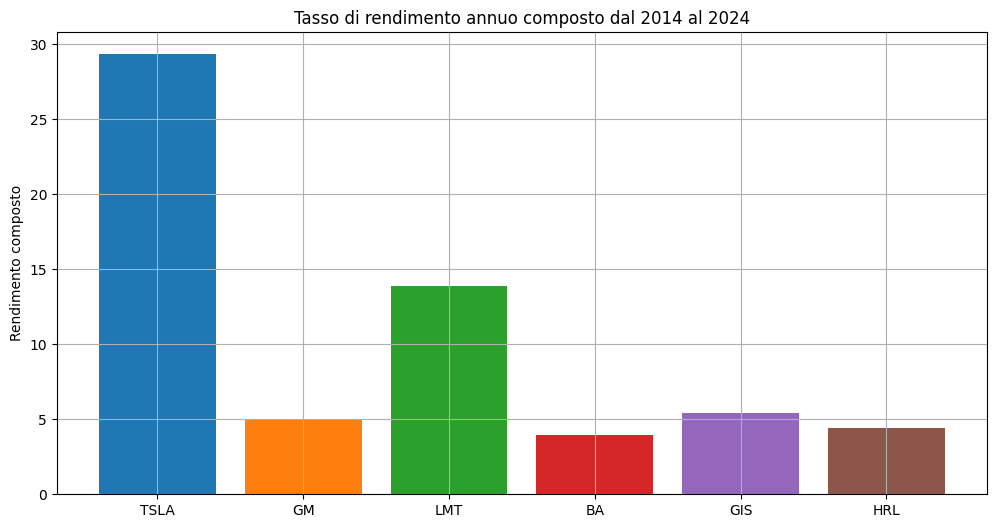

In [7]:
plt.figure(figsize=(12, 6))
for ticker in tickers:
    cagr = (data.Close[ticker].iloc[-1] / data.Close[ticker].iloc[0]) ** (1 / num_years) - 1
    print(f"{ticker}: {cagr:.2%}")
    plt.bar(ticker, cagr*100)

plt.title('Tasso di rendimento annuo composto dal 2014 al 2024')
plt.ylabel("Rendimento composto")
plt.grid(True)   
plt.show()

## Grafici Rendimento semplice e Rendimento logaritmico

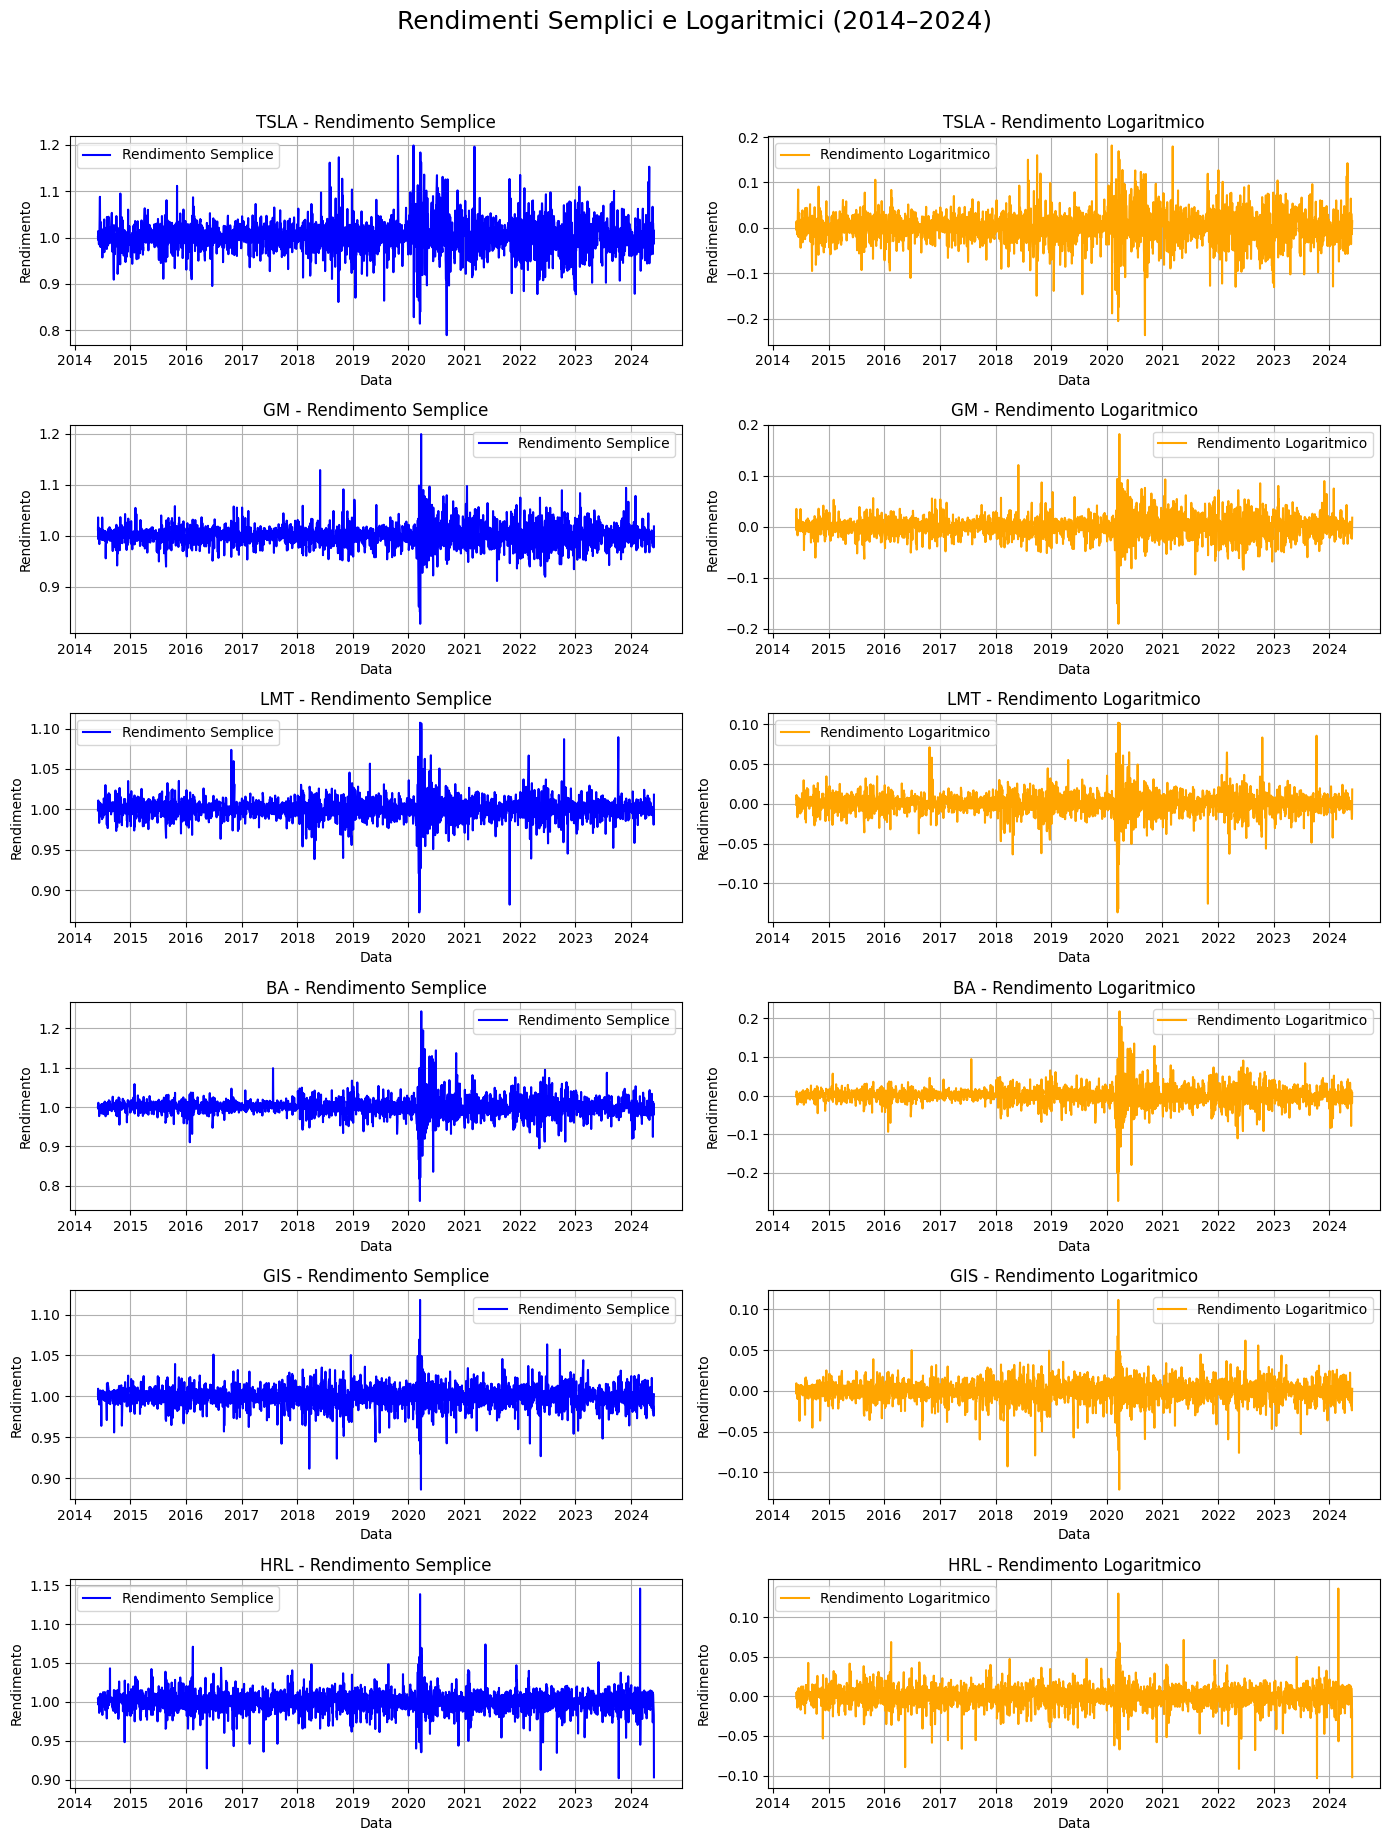

In [8]:
# Creazione grafo
fig, axes = plt.subplots(nrows=len(tickers), ncols=2, figsize=(14, 3 * len(tickers)))
fig.suptitle('Rendimenti Semplici e Logaritmici (2014–2024)', fontsize=18, y=1.02)

rit_gros = pd.DataFrame()
rit_log = pd.DataFrame()

for i, ticker in enumerate(tickers):
    ticker_prices = data['Close'][ticker].dropna()
    
    simple_returns = (ticker_prices / ticker_prices.shift(1))
    log_returns = np.log(ticker_prices / ticker_prices.shift(1))

    rit_gros[ticker] = simple_returns
    rit_log[ticker] = log_returns

    # rendimento semplice
    axes[i, 0].plot(simple_returns, color='blue', label='Rendimento Semplice')
    axes[i, 0].set_title(f'{ticker} - Rendimento Semplice')
    axes[i, 0].set_xlabel('Data')
    axes[i, 0].set_ylabel('Rendimento')
    axes[i, 0].grid(True)
    axes[i, 0].legend()

    # rendimento logaritmico
    axes[i, 1].plot(log_returns, color='orange', label='Rendimento Logaritmico')
    axes[i, 1].set_title(f'{ticker} - Rendimento Logaritmico')
    axes[i, 1].set_xlabel('Data')
    axes[i, 1].set_ylabel('Rendimento')
    axes[i, 1].grid(True)
    axes[i, 1].legend()

plt.tight_layout()
plt.subplots_adjust(top=0.95) 
plt.show()


## Grafici diagnostici a tre sezioni

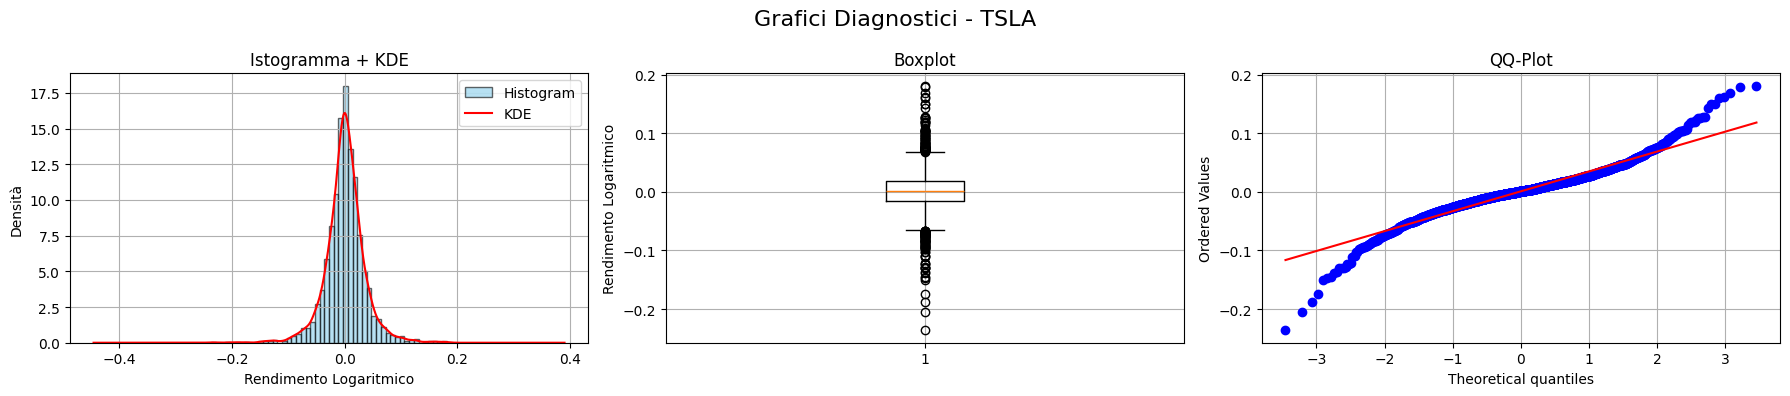

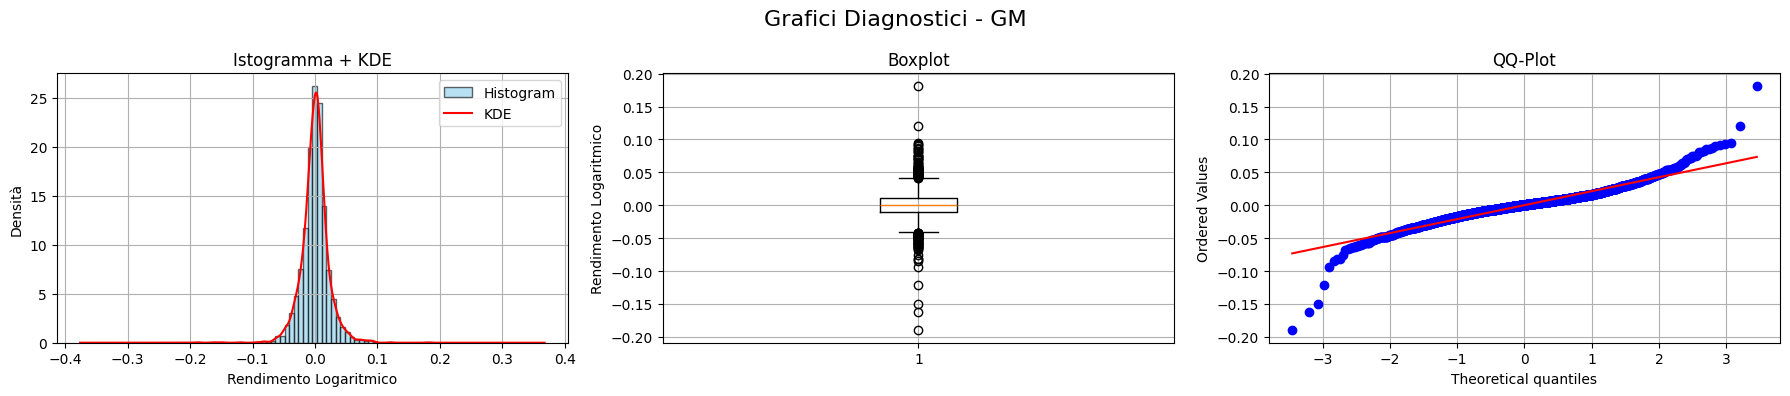

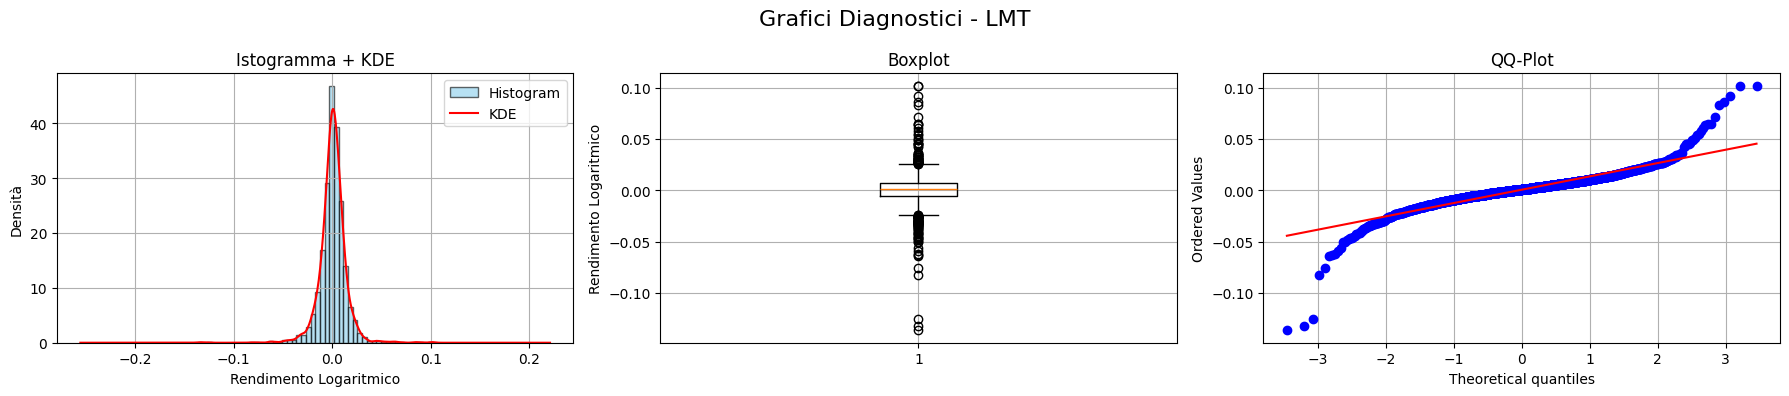

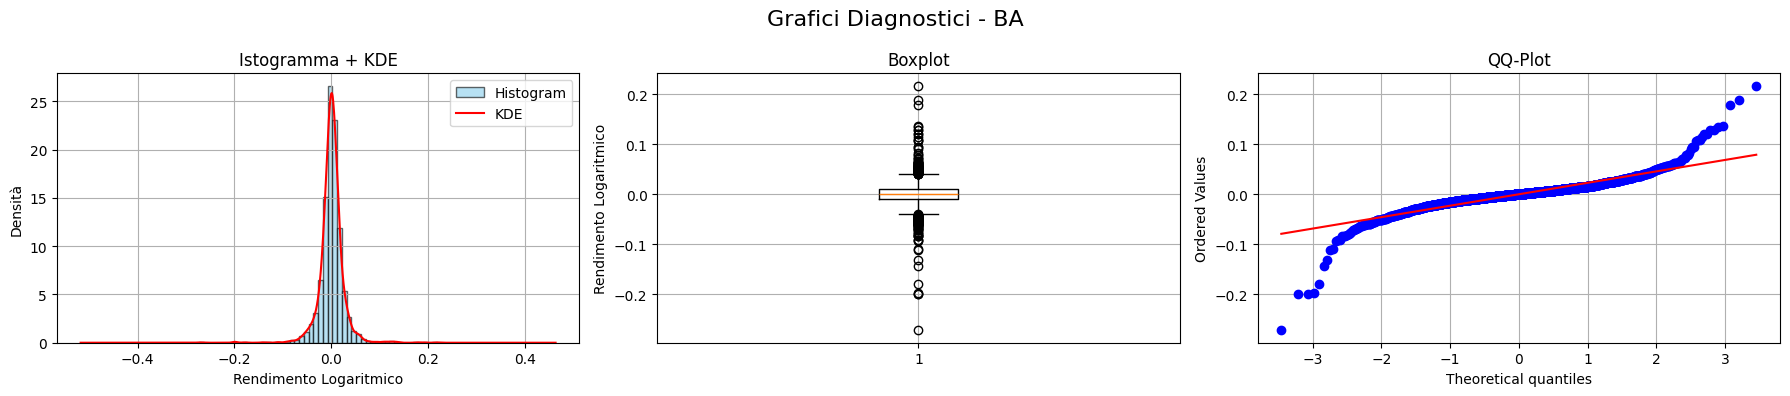

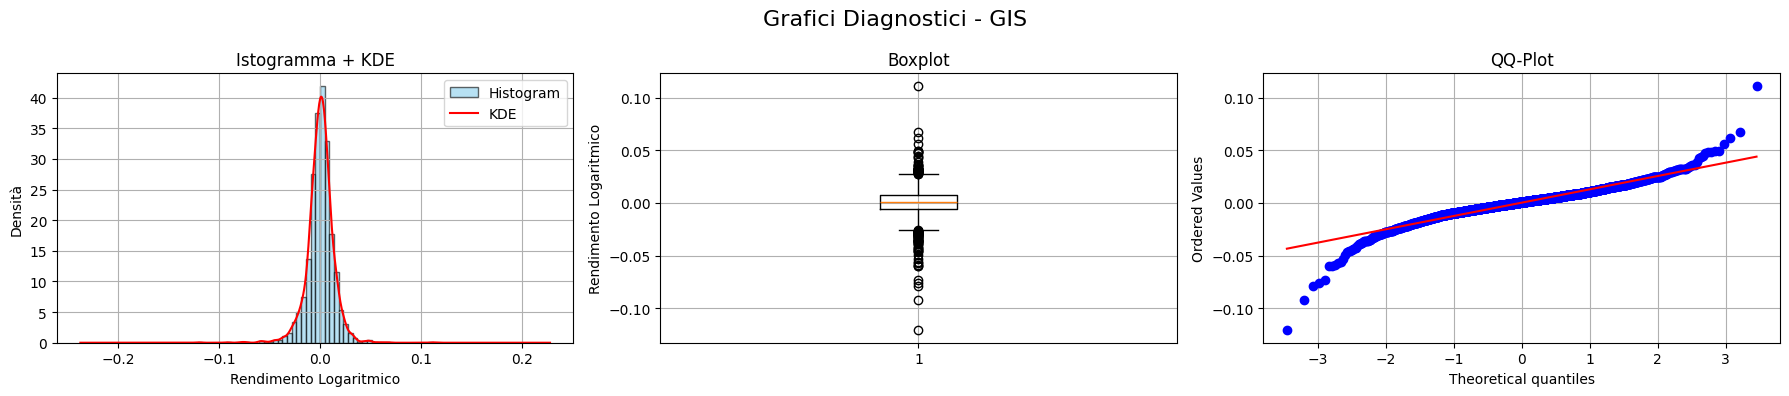

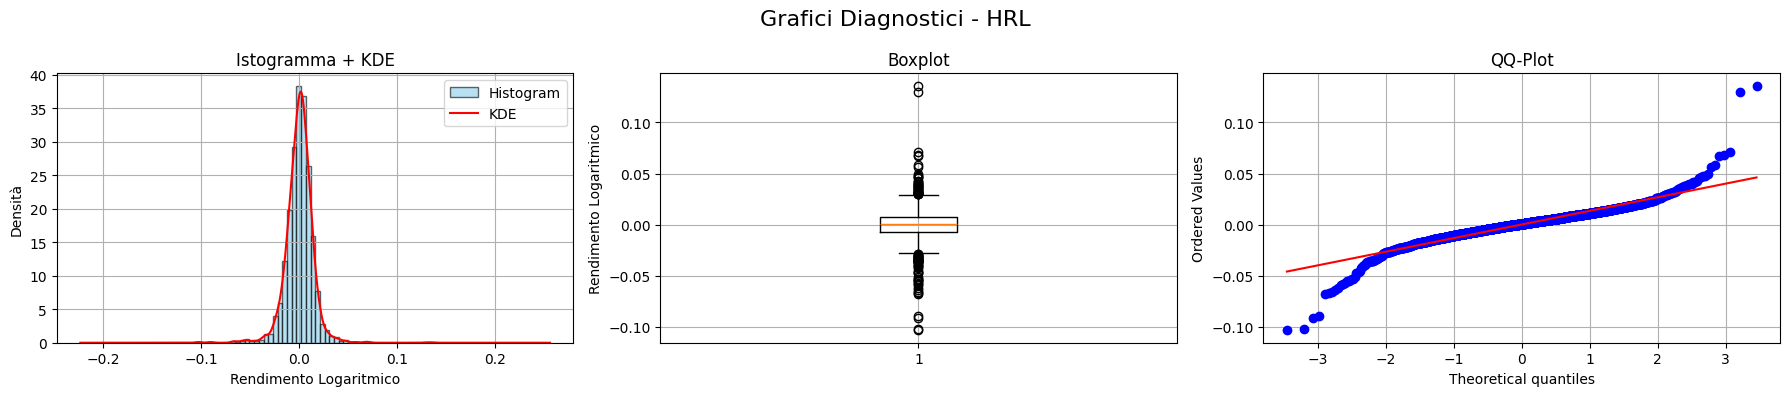

In [31]:
def diagnostic_plots(returns, ticker):
    fig, axs = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f'Grafici Diagnostici - {ticker}', fontsize=16)

    # Istogramma con KDE
    axs[0].hist(returns.dropna(), bins=50, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Histogram')
    returns.dropna().plot(kind='kde', ax=axs[0], color='red', label='KDE')
    axs[0].set_title('Istogramma + KDE')
    axs[0].set_xlabel('Rendimento Logaritmico')
    axs[0].set_ylabel('Densità')
    axs[0].legend()
    axs[0].grid(True)

    # Boxplot
    axs[1].boxplot(returns.dropna(), vert=True)
    axs[1].set_title('Boxplot')
    axs[1].set_ylabel('Rendimento Logaritmico')
    axs[1].grid(True)

    # QQ-plot
    stats.probplot(returns.dropna().to_numpy().flatten(), dist="norm", plot=axs[2])
    axs[2].set_title('QQ-Plot')
    axs[2].grid(True)

    plt.tight_layout()
    plt.show()

# Applicazione per ciascun ticker
for ticker in tickers:
    diagnostic_plots(rit_log[ticker], ticker)



## Statistiche descrittive univariate annualizzate media, varianza, deviazione standard, asimmetria, curtosi

In [10]:
# Dizionario per salvare le statistiche
statistiche = []

# Giorni di trading per anno
trading_days = 252  

for ticker in tickers:

    mean_ann = (rit_log[ticker].mean() * trading_days)
    var_ann = (rit_log[ticker].var() * trading_days)
    std_ann = (rit_log[ticker].std() * np.sqrt(trading_days))
    skewness = rit_log[ticker].skew()
    kurtosis = rit_log[ticker].kurtosis()
    
    statistiche.append({
        'Ticker': ticker,
        'Media': mean_ann,
        'Varianza': var_ann,
        'Dev. Standard': std_ann,
        'Asimmetria': skewness,
        'Curtosi': kurtosis
    })

# Creazione DataFrame delle statistiche
stats_df = pd.DataFrame(statistiche)
print(stats_df.round(4))


  Ticker   Media  Varianza  Dev. Standard  Asimmetria  Curtosi
0   TSLA  0.2577    0.3078         0.5548     -0.1273   4.5663
1     GM  0.0487    0.1220         0.3493     -0.1426   7.9943
2    LMT  0.1300    0.0491         0.2216     -0.6223  15.8244
3     BA  0.0386    0.1585         0.3981     -0.5212  18.6974
4    GIS  0.0530    0.0436         0.2088     -0.6118   8.7954
5    HRL  0.0433    0.0496         0.2228     -0.0950  12.0743


## Matrice di varianze/covarianze e di correlazione dei rendimenti mensili.

In [11]:
# Dizionario per salvare i log returns mensili di ciascun ticker
monthly_log_returns = pd.DataFrame()

for ticker in tickers:
    monthly_ret = rit_log[ticker].resample('ME').sum()
    monthly_log_returns[ticker] = monthly_ret

# Calcolo delle matrici
cov_matrix = monthly_log_returns.cov()
corr_matrix = monthly_log_returns.corr()

print("Matrice di Varianze/Covarianze (Rendimenti Mensili):")
print(cov_matrix.round(4))

print("\nMatrice di Correlazione (Rendimenti Mensili):")
print(corr_matrix.round(4))

Matrice di Varianze/Covarianze (Rendimenti Mensili):
        TSLA      GM     LMT      BA     GIS     HRL
TSLA  0.0268  0.0059 -0.0007  0.0038 -0.0002  0.0011
GM    0.0059  0.0091  0.0011  0.0056  0.0006  0.0007
LMT  -0.0007  0.0011  0.0034  0.0028  0.0010  0.0002
BA    0.0038  0.0056  0.0028  0.0132  0.0005 -0.0000
GIS  -0.0002  0.0006  0.0010  0.0005  0.0026  0.0010
HRL   0.0011  0.0007  0.0002 -0.0000  0.0010  0.0037

Matrice di Correlazione (Rendimenti Mensili):
        TSLA      GM     LMT      BA     GIS     HRL
TSLA  1.0000  0.3778 -0.0761  0.2027 -0.0189  0.1150
GM    0.3778  1.0000  0.1936  0.5102  0.1226  0.1209
LMT  -0.0761  0.1936  1.0000  0.4173  0.3477  0.0482
BA    0.2027  0.5102  0.4173  1.0000  0.0895 -0.0021
GIS  -0.0189  0.1226  0.3477  0.0895  1.0000  0.3229
HRL   0.1150  0.1209  0.0482 -0.0021  0.3229  1.0000


## Grafico delle correlazioni fra i titoli

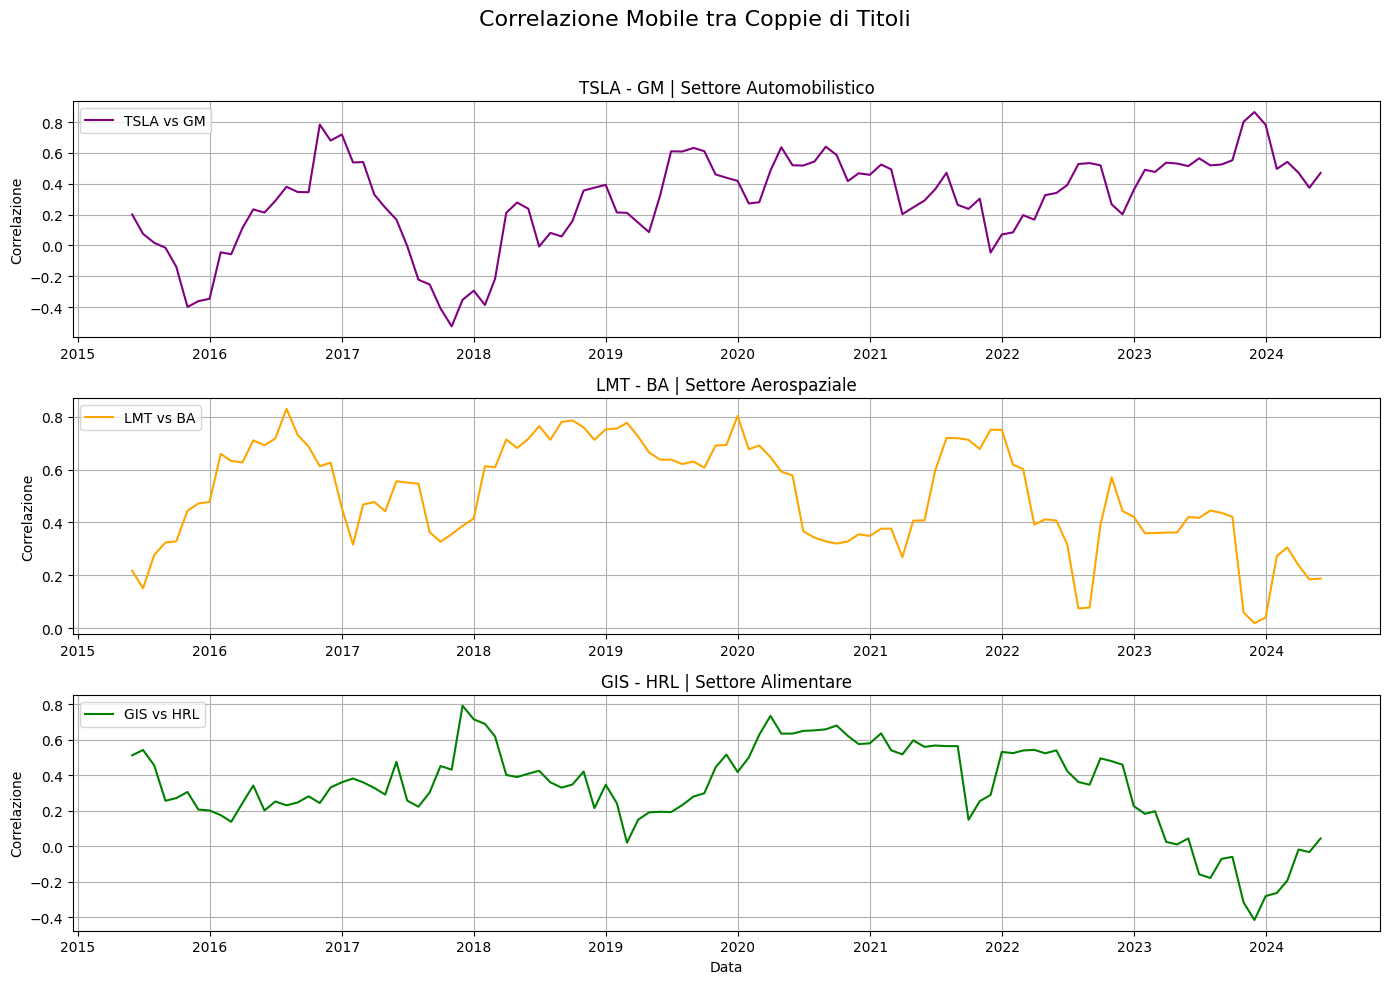

In [12]:
coppie = [('TSLA', 'GM'), ('LMT', 'BA'), ('GIS', 'HRL')]
settori = ['Settore Automobilistico', 'Settore Aerospaziale', 'Settore Alimentare']
colori = ['purple', 'orange', 'green']
window = 12

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 10), sharex=True)
fig.suptitle('Correlazione Mobile tra Coppie di Titoli', fontsize=16)

for i, (t1, t2) in enumerate(coppie):
    rolling_corr = monthly_log_returns[t1].rolling(window=window).corr(monthly_log_returns[t2])
    
    axes[i].plot(rolling_corr, label=f'{t1} vs {t2}', color=colori[i])
    axes[i].set_ylabel('Correlazione')
    axes[i].set_title(f'{t1} - {t2} | {settori[i]}')
    axes[i].grid(True)
    axes[i].legend(loc='upper left')
    axes[i].tick_params(labelbottom=True)


axes[-1].set_xlabel('Data')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Grafico di dispersione di due titoli dello stesso settore. 

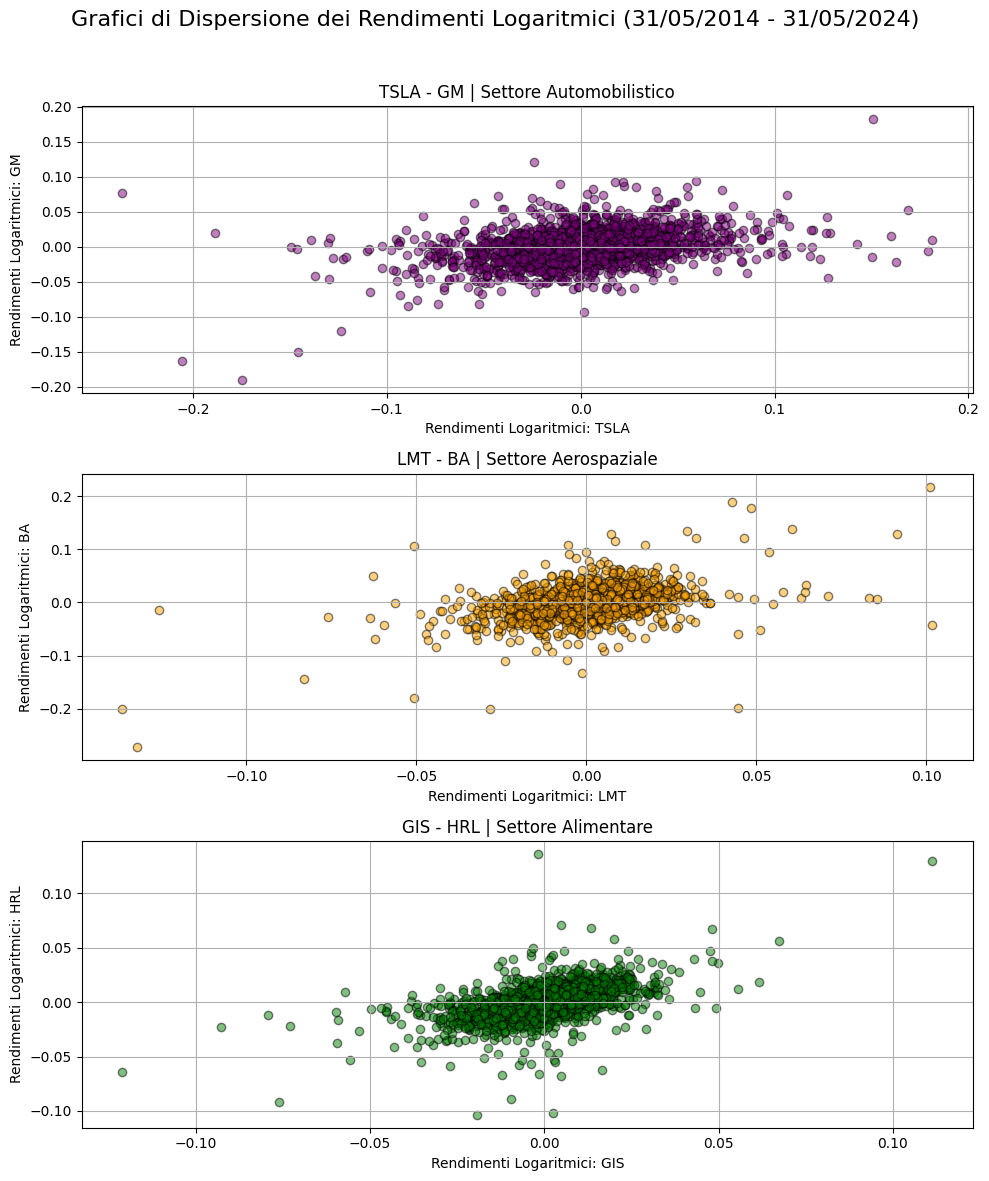

In [13]:
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 12), sharex=False)
fig.suptitle('Grafici di Dispersione dei Rendimenti Logaritmici (31/05/2014 - 31/05/2024)', fontsize=16)

for i, (t1, t2) in enumerate(coppie):
    x = rit_log[t1]
    y = rit_log[t2]
    
    axes[i].scatter(x, y, alpha=0.5, color=colori[i], edgecolor='k')
    axes[i].set_xlabel(f'Rendimenti Logaritmici: {t1}')
    axes[i].set_ylabel(f'Rendimenti Logaritmici: {t2}')
    axes[i].set_title(f'{t1} - {t2} | {settori[i]}')
    axes[i].grid(True)



plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## Grafico dei rendimenti dei due titoli dello stesso settore

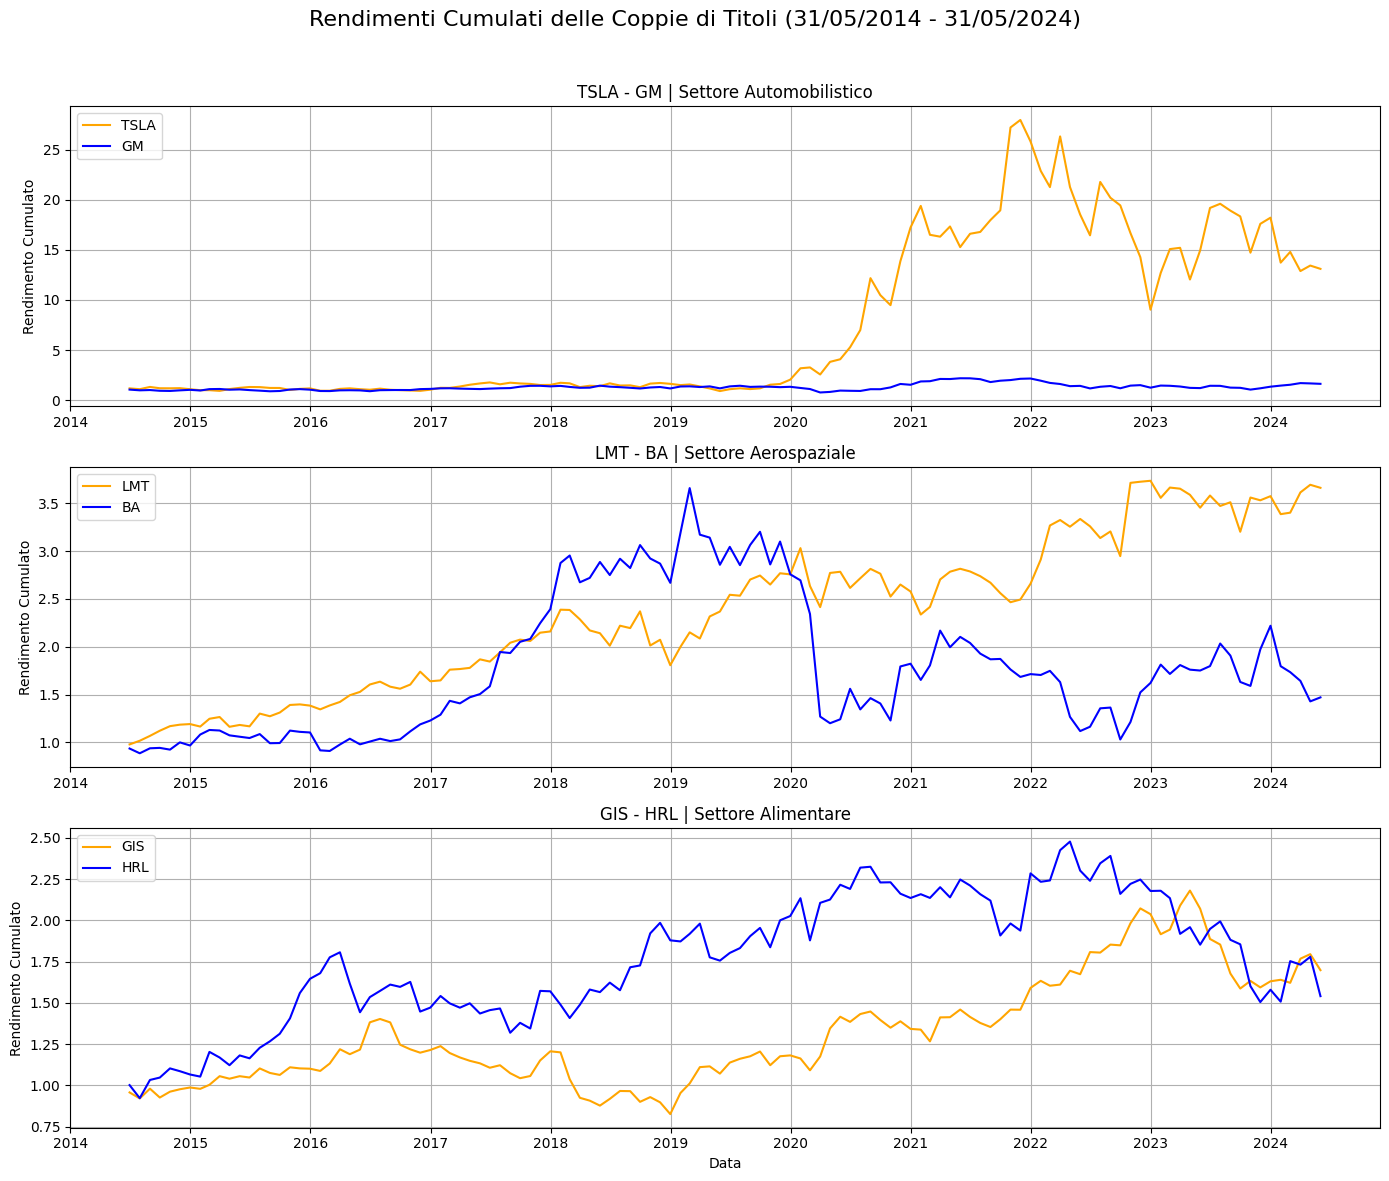

In [14]:
# Creazione grafico
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 12), sharex=True)
fig.suptitle('Rendimenti Cumulati delle Coppie di Titoli (31/05/2014 - 31/05/2024)', fontsize=16)

for i, ((t1, t2), settore, colore) in enumerate(zip(coppie, settori, colori)):
    returns_pair = monthly_log_returns[[t1, t2]].dropna()

    cumulative_returns = np.exp(returns_pair.cumsum())

    axes[i].plot(cumulative_returns.index, cumulative_returns[t1], label=t1, color='orange')
    axes[i].plot(cumulative_returns.index, cumulative_returns[t2], label=t2, color='blue')
    axes[i].set_title(f'{t1} - {t2} | {settori[i]}')
    axes[i].set_ylabel('Rendimento Cumulato')
    axes[i].grid(True)
    axes[i].legend(loc='upper left')
    axes[i].tick_params(labelbottom=True)

axes[-1].set_xlabel('Data')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## Modello di previsione ARIMA

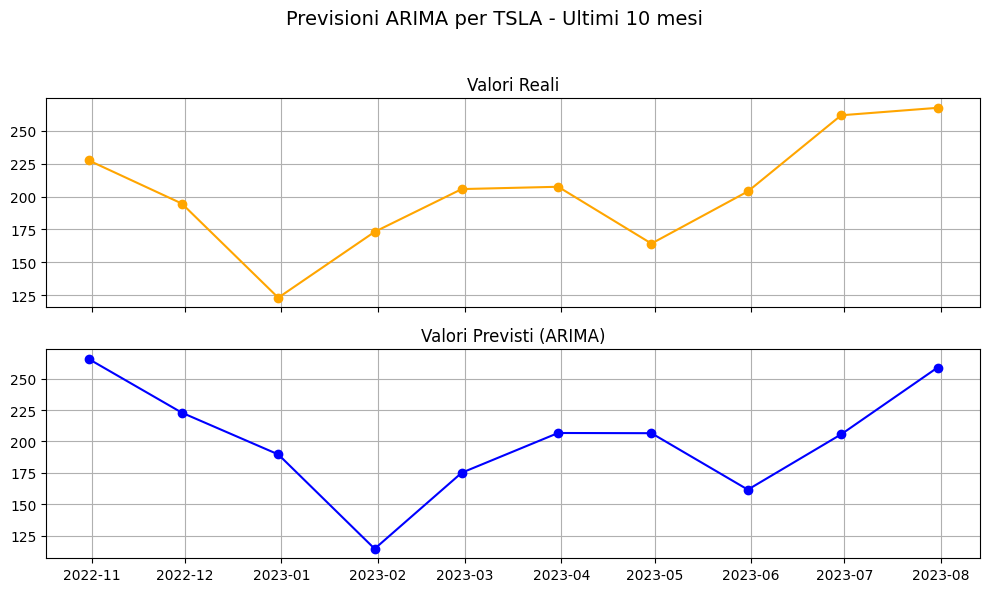

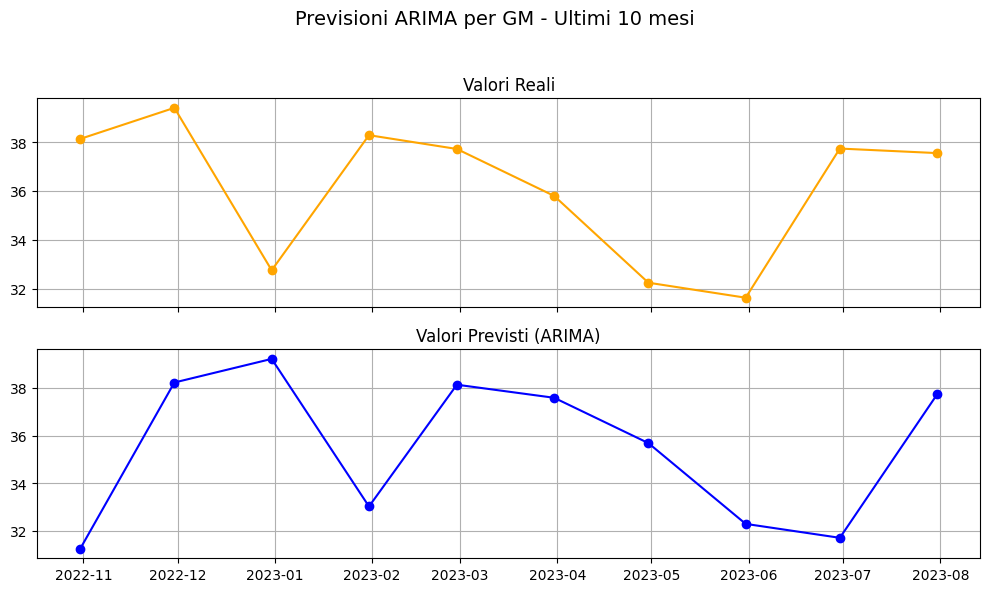

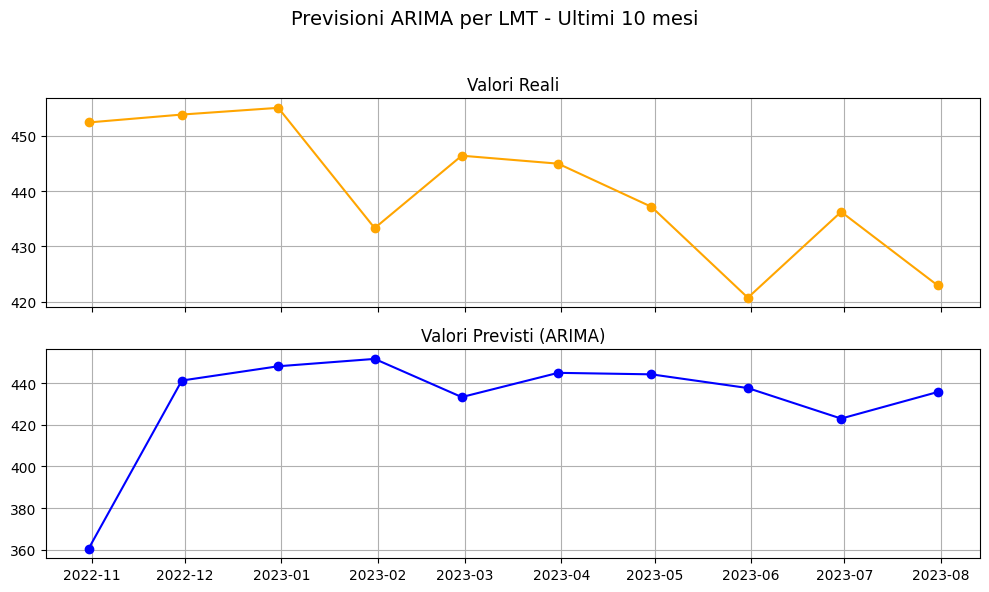

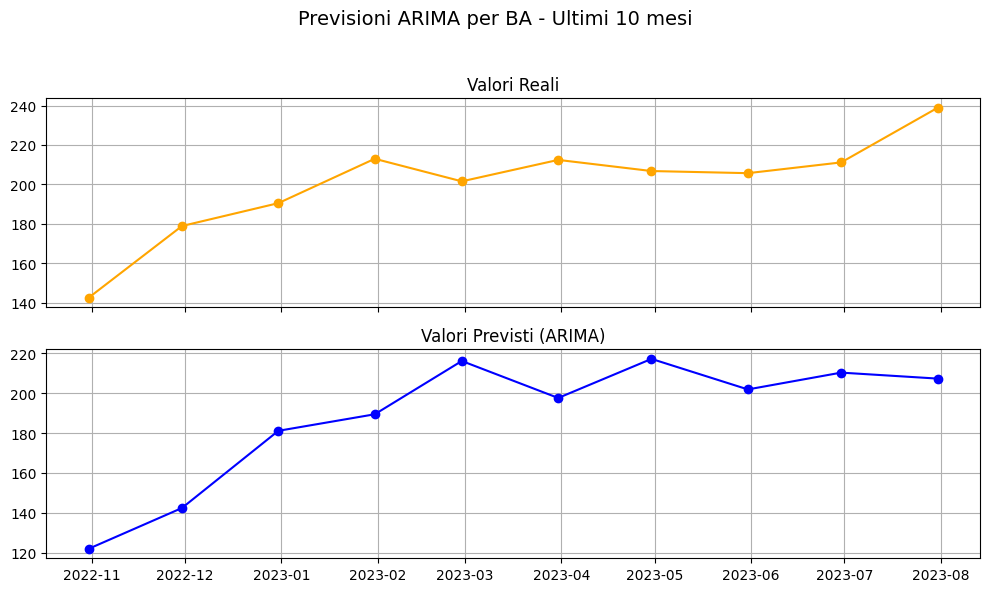

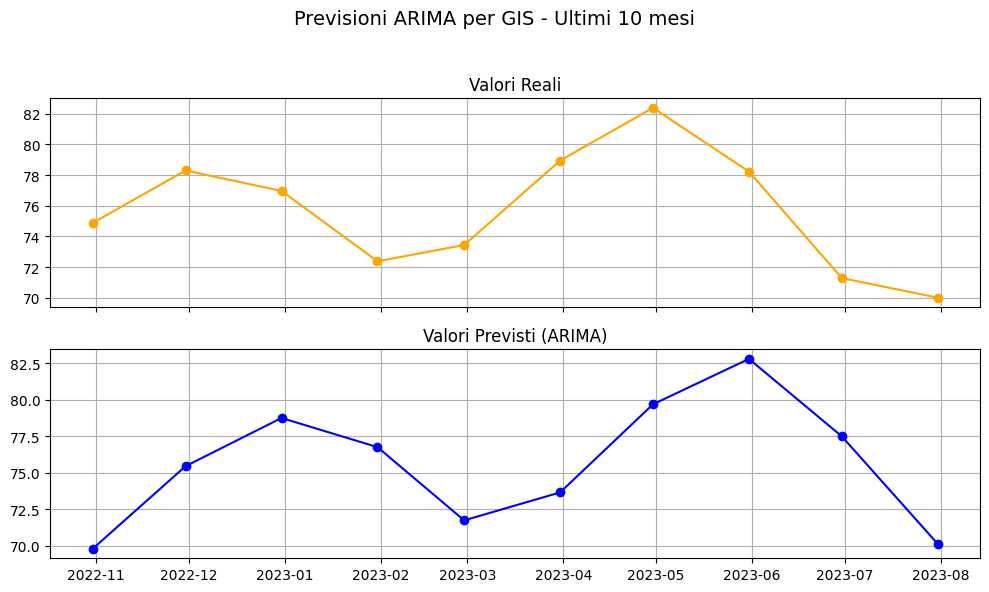

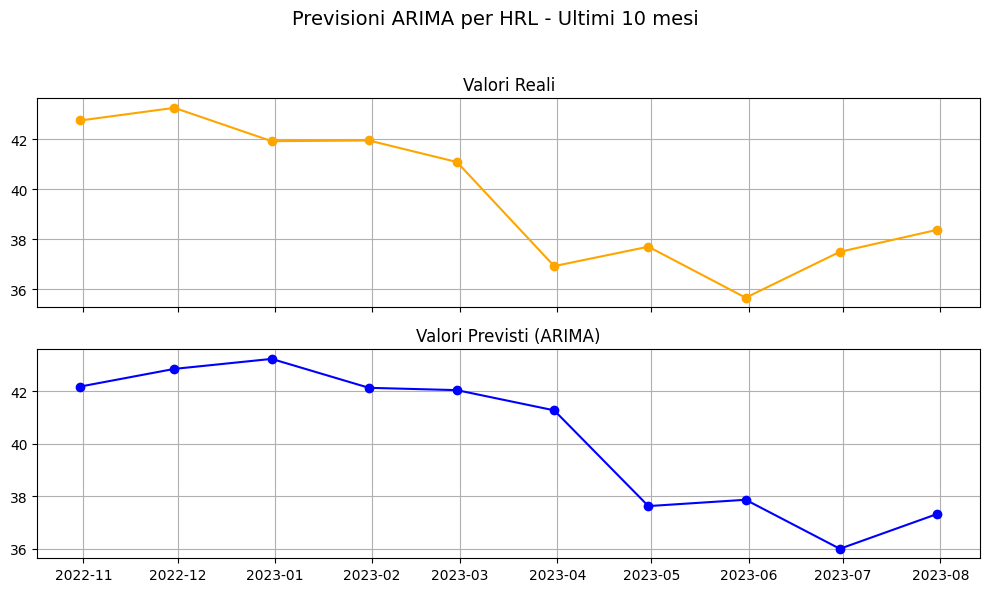

  Ticker      MAE
0   TSLA  37.2128
1     GM   3.2321
2    LMT  19.3001
3     BA  16.6038
4    GIS   3.4683
5    HRL   1.2605


In [ ]:
# Sopprime i warning
warnings.filterwarnings("ignore")

monthly_close = data['Close'].resample('ME').last()

# Periodi: 80 mesi train, 30 test, 10 forecast
train_len = 80
test_len = 30
prev_len = 10

results = []

for ticker in tickers:
    ticker_prices = monthly_close[ticker].dropna()
    train_data = ticker_prices.iloc[:train_len]
    test_data = ticker_prices.iloc[train_len:train_len + test_len]

    predictions = []
    actuals = test_data[-prev_len:]
    history = list(train_data.values) + list(test_data[:-prev_len].values)

    for t in range(prev_len):
        # Test di Dickey-Fuller
        adf_result = adfuller(history)
        adf_stat = adf_result[0]
        p_value = adf_result[1]
        is_stationary = p_value < 0.05

        # parametri ARIMA: differenziazione solo se non stazionario
        d = 0 if is_stationary else 1
        model = ARIMA(history, order=(1, d, 1))
        model_fit = model.fit()
        forecast = model_fit.forecast()[0]
        predictions.append(forecast)

        # aggiorna lo storico
        history.append(actuals.iloc[t])

    # Calcolo MAE
    mae = mean_absolute_error(actuals, predictions)

    results.append({
        'Ticker': ticker,
        'MAE': mae,
        'Valori Reali': actuals.values,
        'Previsioni': predictions,
        'Date': actuals.index
    })

    fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    fig.suptitle(f'Previsioni ARIMA per {ticker} - Ultimi 10 mesi', fontsize=14)

    axs[0].plot(actuals.index, actuals.values, marker='o', color='orange')
    axs[0].set_title('Valori Reali')
    axs[0].grid(True)

    axs[1].plot(actuals.index, predictions, marker='o', color='blue')
    axs[1].set_title('Valori Previsti (ARIMA)')
    axs[1].grid(True)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Tabella MAE finale
results_df = pd.DataFrame(results)
print(results_df[['Ticker', 'MAE']].round(4))

## Strategia di trading con backtest

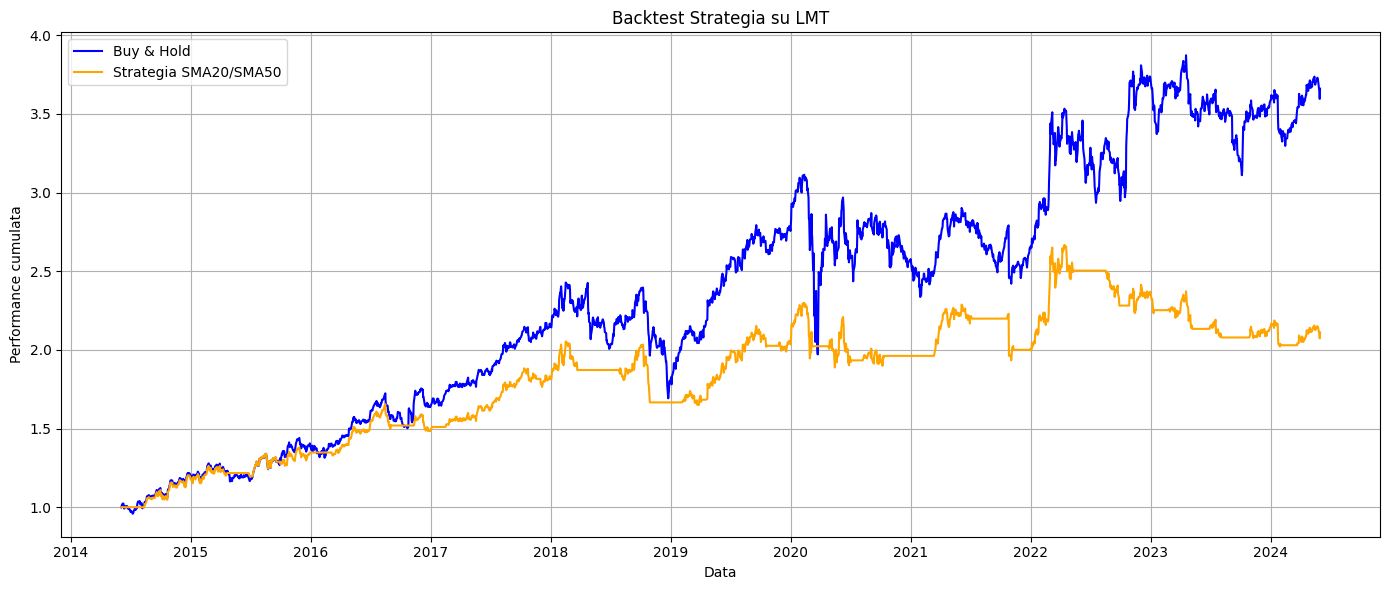

In [17]:
# Parametri
ticker = 'LMT'
short_window = 20
long_window = 50

data_strategia = data['Close'][ticker].to_frame().copy()
data_strategia.columns = ['Close']
data_strategia.dropna(inplace=True)

# medie mobili
data_strategia['SMA20'] = data_strategia['Close'].rolling(window=short_window).mean()
data_strategia['SMA50'] = data_strategia['Close'].rolling(window=long_window).mean()

# Genera segnali di trading
data_strategia['Signal'] = 0
data_strategia.loc[data_strategia['SMA20'] > data_strategia['SMA50'], 'Signal'] = 1

# rendimenti giornalieri
data_strategia['Return'] = data_strategia['Close'].pct_change()
data_strategia['Strategy_Return'] = data_strategia['Signal'].shift(1) * data_strategia['Return']

# performance cumulata
data_strategia['Cumulative_Market'] = (1 + data_strategia['Return']).cumprod()
data_strategia['Cumulative_Strategy'] = (1 + data_strategia['Strategy_Return']).cumprod()

# Stampa grafico
plt.figure(figsize=(14, 6))
plt.plot(data_strategia['Cumulative_Market'], label='Buy & Hold', color='blue')
plt.plot(data_strategia['Cumulative_Strategy'], label='Strategia SMA20/SMA50', color='orange')
plt.title(f'Backtest Strategia su {ticker}')
plt.xlabel('Data')
plt.ylabel('Performance cumulata')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Grafico Strategia con Buy e Sell

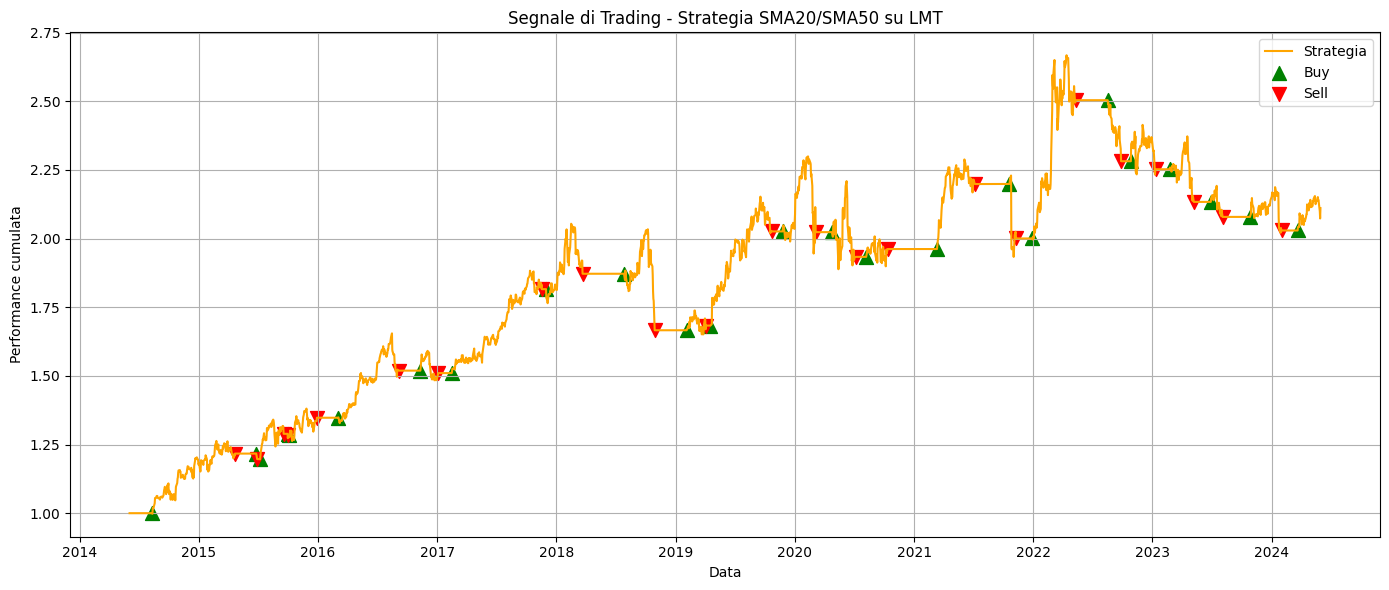

In [18]:
# Segnali di acquisto e vendita
data_strategia['Trade_Signal'] = data_strategia['Signal'].diff()
buy_signals = data_strategia[data_strategia['Trade_Signal'] == 1]
sell_signals = data_strategia[data_strategia['Trade_Signal'] == -1]

# Grafico solo della strategia con segnali
plt.figure(figsize=(14, 6))
plt.plot(data_strategia['Cumulative_Strategy'], label='Strategia', color='orange')

# Triangoli verdi per acquisti
plt.scatter(buy_signals.index, buy_signals['Cumulative_Strategy'],
            marker='^', color='green', s=100, label='Buy')

# Triangoli rossi per vendite
plt.scatter(sell_signals.index, sell_signals['Cumulative_Strategy'],
            marker='v', color='red', s=100, label='Sell')

plt.title(f'Segnale di Trading - Strategia SMA20/SMA50 su LMT')
plt.xlabel('Data')
plt.ylabel('Performance cumulata')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Efficienza della strategia rispetto alla detenzione del titolo per tutto il periodo (“Buy & Hold”)

In [19]:
performance_strategia = (data_strategia['Cumulative_Strategy'].iloc[-1] - 1) * 100
performance_buy_hold = (data_strategia['Cumulative_Market'] - 1) * 100

volatilita_strategia = data_strategia['Cumulative_Strategy'].std() * np.sqrt(252)
volatilita_buy_hold = data_strategia['Cumulative_Market'].std() * np.sqrt(252)

sharpe_strategia = data_strategia['Cumulative_Strategy'].mean() / data_strategia['Cumulative_Strategy'].std() * np.sqrt(252)
sharpe_buy_hold = data_strategia['Cumulative_Market'].mean() / data_strategia['Cumulative_Market'].std() * np.sqrt(252)

def max_drawdown(cumulative_returns):
    peak = cumulative_returns.cummax()
    drawdown = (cumulative_returns - peak) / peak
    return drawdown.min()

max_dd_strategia = max_drawdown(data_strategia['Cumulative_Strategy'])
max_dd_buy_hold = max_drawdown(data_strategia['Cumulative_Market'])

print(f"Performance Strategia: {performance_strategia:.2f}%")
print(f"Performance Buy & Hold: {performance_buy_hold.iloc[-1]:.2f}%\n")

print(f"Volatilità Strategia (ann.): {volatilita_strategia:.4f}")
print(f"Volatilità Buy & Hold (ann.): {volatilita_buy_hold:.4f}\n")

print(f"Sharpe Ratio Strategia: {sharpe_strategia:.4f}")
print(f"Sharpe Ratio Buy & Hold: {sharpe_buy_hold:.4f}\n")

print(f"Max Drawdown Strategia: {max_dd_strategia:.2%}")
print(f"Max Drawdown Buy & Hold: {max_dd_buy_hold:.2%}")


Performance Strategia: 111.09%
Performance Buy & Hold: 266.08%

Volatilità Strategia (ann.): 6.1693
Volatilità Buy & Hold (ann.): 12.6431

Sharpe Ratio Strategia: 74.8914
Sharpe Ratio Buy & Hold: 47.0321

Max Drawdown Strategia: -24.23%
Max Drawdown Buy & Hold: -36.67%


## CAPM
### Calcolo beta di ciascun titolo

In [20]:
# Ticker dell'indice di mercato
market_ticker = '^GSPC'

market_data = yf.download(market_ticker, start=start_date, end=end_date)['Close']
market_returns = np.log(market_data.resample('ME').last() / market_data.resample('ME').last().shift(1)).dropna()
market_returns.name = 'Market'

# Tasso privo di rischio (5%)
rf_annual = 0.05
rf_monthly = (1 + rf_annual)**(1/12) - 1

betas = {}

for ticker in tickers:
    ri = monthly_log_returns[ticker].dropna()
    ri, rm = ri.align(market_returns, join='inner')

    # Excess returns
    ri_excess = ri - rf_monthly
    rm_excess = rm - rf_monthly

    # Regressione lineare OLS
    X = sm.add_constant(rm_excess)
    model = sm.OLS(ri_excess, X).fit()
    beta = model.params.iloc[1]
    
    betas[ticker] = beta
    print(f"Beta di {ticker}: {beta:.4f}")


[*********************100%***********************]  1 of 1 completed

Beta di TSLA: 1.6721
Beta di GM: 1.4476
Beta di LMT: 0.6085
Beta di BA: 1.5278
Beta di GIS: 0.2975
Beta di HRL: 0.2115


## Rendimento atteso annuo 

In [21]:
expected_annuale = 0.08 
expected_mensile = (1 + expected_annuale)**(1/12) - 1

expected_returns = {}

for ticker in betas:
    expected_r = rf_monthly + betas[ticker] * (expected_mensile - rf_monthly)
    expected_annuo = (1 + expected_r)**12 - 1
    expected_returns[ticker] = expected_annuo
    print(f"Rendimento atteso annuo per {ticker}: {expected_annuo:.2%}")


Rendimento atteso annuo per TSLA: 10.06%
Rendimento atteso annuo per GM: 9.37%
Rendimento atteso annuo per LMT: 6.82%
Rendimento atteso annuo per BA: 9.61%
Rendimento atteso annuo per GIS: 5.88%
Rendimento atteso annuo per HRL: 5.63%


## Esposizione di ciascun titolo ai fattori di rischio Fama-French

In [ ]:
#Download dati FF
zip_file_path = "C:/Users/filge/Downloads/F-F_Research_Data_Factors_TXT.zip"

try:
    with zipfile.ZipFile(zip_file_path, 'r') as z:
        file_names = z.namelist()
        txt_file_name = None
        for name in file_names:
            if name.endswith('.txt'):
                txt_file_name = name
                break
        if txt_file_name is None:
            raise ValueError(f"File TXT non trovato nello zip: {zip_file_path}. Contenuto dello zip: {file_names}")

        with z.open(txt_file_name) as file:
            content = file.read().decode('utf-8')

    lines = content.split('\n')
    
    actual_data_start_line = -1
    actual_data_end_line = -1
    
    for k in range(len(lines)):
        line = lines[k].strip()
        if len(line) > 3 and line[:4].isdigit():
            actual_data_start_line = k
            break
    
    if actual_data_start_line == -1:
        raise ValueError("Impossibile trovare l'inizio dei dati numerici nel file TXT.")

    for k in range(actual_data_start_line, len(lines)):
        line = lines[k].strip()
        if not line: 
            actual_data_end_line = k
            break
        if len(line) > 3 and not line[:4].isdigit() and not line.startswith('-'): 
             actual_data_end_line = k
             break
    if actual_data_end_line == -1: 
        actual_data_end_line = len(lines) 

    data_content = "\n".join(lines[actual_data_start_line:actual_data_end_line])

    headers = ['Date', 'Mkt-Rf', 'SMB', 'HML', 'RF'] 
    df_ff = pd.read_csv(io.StringIO(data_content), delim_whitespace=True, header=None, names=headers)

    df_ff['Date'] = pd.to_datetime(df_ff['Date'], format='%Y%m') 
    df_ff.set_index('Date', inplace=True)

    for col in df_ff.columns:
        df_ff[col] = pd.to_numeric(df_ff[col], errors='coerce') / 100 

    df_ff = df_ff[(df_ff.index >= start_date) & (df_ff.index <= end_date)]

    print(df_ff.head())
    print(df_ff.tail())

except FileNotFoundError:
    print(f"Errore: Il file '{zip_file_path}' non è stato trovato.")
except zipfile.BadZipFile:
    print(f"Errore: Il file '{zip_file_path}' non è un archivio ZIP valido.")
except ValueError as e:
    print(f"Errore nel parsing del contenuto: {e}")
except Exception as e:
    print(f"Si è verificato un errore inatteso: {e}")


            Mkt-Rf     SMB     HML   RF
Date                                   
2014-06-01  0.0261  0.0309 -0.0070  0.0
2014-07-01 -0.0204 -0.0430  0.0004  0.0
2014-08-01  0.0424  0.0040 -0.0045  0.0
2014-09-01 -0.0197 -0.0370 -0.0135  0.0
2014-10-01  0.0252  0.0420 -0.0180  0.0
            Mkt-Rf     SMB     HML      RF
Date                                      
2024-01-01  0.0070 -0.0502 -0.0247  0.0047
2024-02-01  0.0507 -0.0022 -0.0352  0.0042
2024-03-01  0.0283 -0.0251  0.0422  0.0043
2024-04-01 -0.0467 -0.0239 -0.0052  0.0047
2024-05-01  0.0434  0.0078 -0.0167  0.0044


In [23]:
monthly_gross_returns = pd.DataFrame()

for ticker in tickers:
    monthly_ret = rit_gros[ticker].resample('M').apply(lambda x: (x + 1).prod() - 1)
    monthly_gross_returns[ticker] = monthly_ret

monthly_gross_returns.index = monthly_gross_returns.index.to_period('M').to_timestamp()

excess_returns = pd.DataFrame()

#Calcolo rendimenti in eccesso
for ticker in tickers:
    ri = monthly_gross_returns[ticker].loc[df_ff.index]
    rf = df_ff['RF']
    excess_rit = ri - rf
    excess_returns[ticker] = excess_rit

#Regressione per ciascun titolo
X = df_ff[['Mkt-Rf', 'SMB', 'HML']]
X = sm.add_constant(X)

for ticker in tickers:
    y = excess_returns[ticker]
    model = sm.OLS(y, X).fit()
    print(f"Risultati per {ticker}")
    print(model.summary())
    print("\n" + "-"*80 + "\n")


Risultati per TSLA
                            OLS Regression Results                            
Dep. Variable:                   TSLA   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     1.573
Date:                Thu, 12 Jun 2025   Prob (F-statistic):              0.200
Time:                        15:35:18   Log-Likelihood:                -1927.1
No. Observations:                 120   AIC:                             3862.
Df Residuals:                     116   BIC:                             3873.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.808e+06   2.18e+05 

## Strategie di trading e backtesting – Strategie dinamiche

### Equal weight

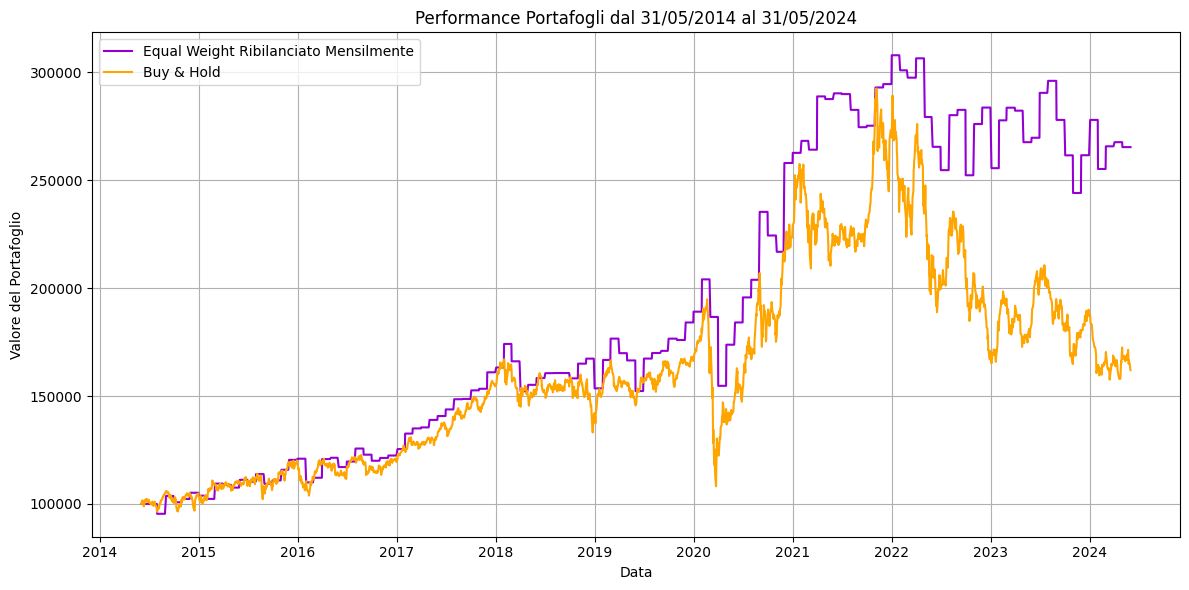

In [ ]:
# strategia equal weight con bilanciamento del portafoglio mensilmente
# Parametri iniziali
initial_capital = 100000
n_assets = len(tickers)
equal_weights = np.repeat(1 / n_assets, n_assets)

# Inizializza lista per valori del portafoglio
cumulative_value = [initial_capital]
dates = [monthly_log_returns.index[0]] 

# Calcolo del valore del portafoglio mese per mese con ribilanciamento
for i in range(1, len(monthly_log_returns)):
    returns = monthly_log_returns.iloc[i] 
    portfolio_return = np.dot(equal_weights, returns)  
    new_value = cumulative_value[-1] * np.exp(portfolio_return)  
    cumulative_value.append(new_value)
    dates.append(monthly_log_returns.index[i])

#Serie temporale del valore cumulato mensile
equal_cumulative_monthly = pd.Series(data=cumulative_value, index=dates)

# Allinea a dati giornalieri per il plot
all_daily_dates = pd.date_range(start=start_date, end=end_date, freq='D')
equal_cumulative_daily_for_plot = equal_cumulative_monthly.reindex(all_daily_dates, method='ffill')
if equal_cumulative_daily_for_plot.index.min() < equal_cumulative_monthly.index.min():
    equal_cumulative_daily_for_plot.iloc[
        0:equal_cumulative_daily_for_plot.index.get_loc(equal_cumulative_monthly.index.min())
    ] = initial_capital


# Strategia Buy & Hold
buy_hold_prices = (1 + rit_log[tickers].dropna()).cumprod()
buy_hold_weights = buy_hold_prices.iloc[0] / buy_hold_prices.iloc[0].sum() 
buy_hold_portfolio = (buy_hold_prices * buy_hold_weights).sum(axis=1)
buy_hold_cumulative = initial_capital * buy_hold_portfolio / buy_hold_portfolio.iloc[0]

# Allinea entrambe le strategie
equal_cumulative_daily_for_plot, buy_hold_cumulative = equal_cumulative_daily_for_plot.align(
    buy_hold_cumulative, join='inner'
)


# Plot
plt.figure(figsize=(12, 6))
plt.plot(equal_cumulative_daily_for_plot, label='Equal Weight Ribilanciato Mensilmente', color='darkviolet')
plt.plot(buy_hold_cumulative, label='Buy & Hold', color='orange')
plt.title(f'Performance Portafogli dal {start_date.strftime("%d/%m/%Y")} al {end_date.strftime("%d/%m/%Y")}')
plt.xlabel('Data')
plt.ylabel('Valore del Portafoglio')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Stop Loss

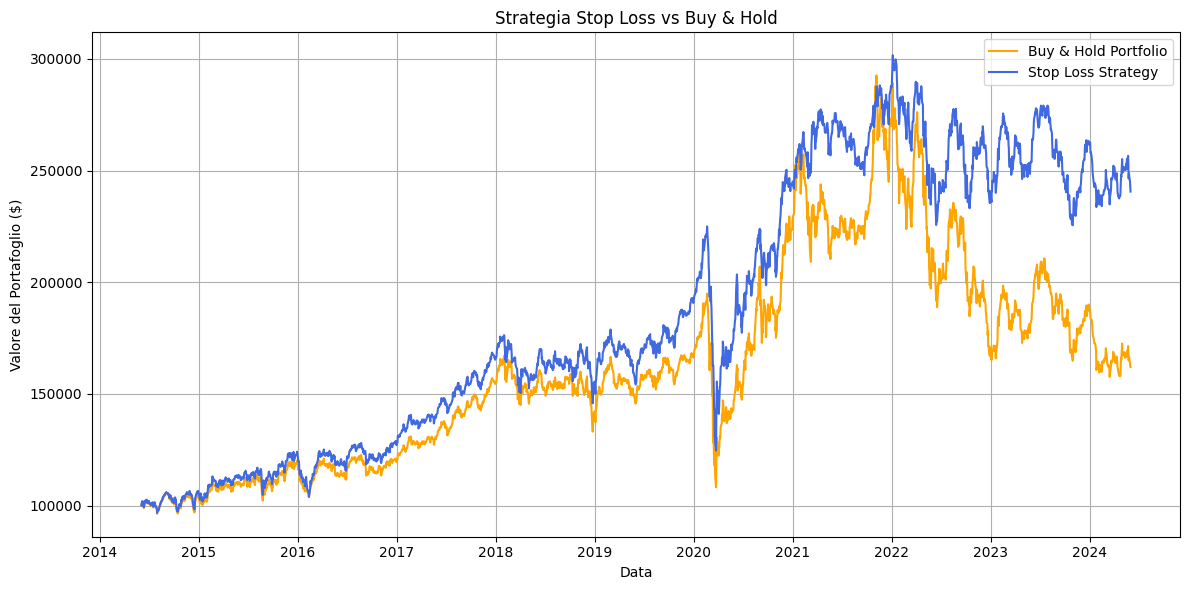

In [ ]:
# Parametri
stop_loss_threshold = -0.05  # uscita dal mercato se perdita mensile > 5%
capital = initial_capital
portfolio_value = [capital]
in_market = True

# Ritorni del portafoglio buy & hold
buy_hold_prices = (1 + rit_log[tickers].dropna()).cumprod()
buy_hold_weights = buy_hold_prices.iloc[0] / buy_hold_prices.iloc[0].sum()
buy_hold_returns = (rit_log[tickers].dropna() @ buy_hold_weights) 

# Strategia Stop Loss
for ret in buy_hold_returns:
    if in_market:
        capital *= np.exp(ret)
        if ret < stop_loss_threshold:
            in_market = False 
    else:
        if ret >= 0: 
            in_market = True
    portfolio_value.append(capital)

# Serie temporale
dates = buy_hold_returns.index.insert(0, buy_hold_returns.index[0])  
stop_loss_series = pd.Series(portfolio_value, index=dates)

# Calcolo valore cumulativo Buy & Hold per confronto
buy_hold_portfolio = (buy_hold_prices * buy_hold_weights).sum(axis=1)
buy_hold_cumulative = initial_capital * buy_hold_portfolio / buy_hold_portfolio.iloc[0]

# Allineamento
stop_loss_series, buy_hold_cumulative = stop_loss_series.align(buy_hold_cumulative, join='inner')

#Plot
plt.figure(figsize=(12, 6))
plt.plot(buy_hold_cumulative, label='Buy & Hold Portfolio', color='orange')
plt.plot(stop_loss_series, label='Stop Loss Strategy', color='royalblue')
plt.title('Strategia Stop Loss vs Buy & Hold')
plt.xlabel('Data')
plt.ylabel('Valore del Portafoglio ($)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### CPPI

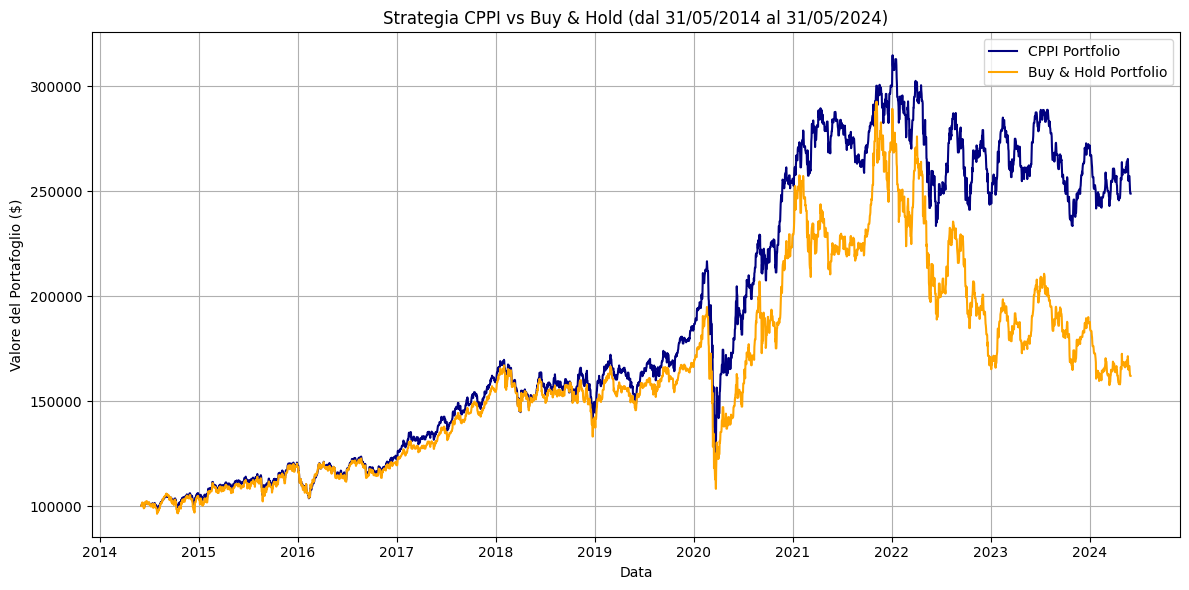

In [ ]:
#CPPI STRATEGY

# Parametri CPPI
initial_capital = 100000
floor_pct = 0.8              # Capitale minimo garantito 
m = 3                        # Moltiplicatore
risk_free_return = 0.0005    # Rendimento mensile stimato 

# Serie di ritorni mensili
returns = rit_log[tickers].dropna()
n_months = returns.shape[0]
dates = returns.index

# Buy & Hold
buy_hold_prices = (1 + returns).cumprod()
buy_hold_weights = buy_hold_prices.iloc[0] / buy_hold_prices.iloc[0].sum()
buy_hold_portfolio = (buy_hold_prices * buy_hold_weights).sum(axis=1)
buy_hold_cumulative = initial_capital * buy_hold_portfolio / buy_hold_portfolio.iloc[0]

cppi_value = [initial_capital]
floor_value = initial_capital * floor_pct
cppi_weights = []

for i in range(n_months):
    cushion = max(cppi_value[-1] - floor_value, 0)
    risky_weight = min(m * cushion / cppi_value[-1], 1)
    safe_weight = 1 - risky_weight
    
    risky_return = returns.iloc[i] @ equal_weights 
    portfolio_return = risky_weight * risky_return + safe_weight * risk_free_return
    
    next_value = cppi_value[-1] * np.exp(portfolio_return)
    cppi_value.append(next_value)
    cppi_weights.append(risky_weight)

# Serie temporale CPPI
cppi_series = pd.Series(cppi_value[1:], index=dates)

# Allineamento mensile giornaliero
all_daily_dates = pd.date_range(start=start_date, end=end_date, freq='D')
cppi_daily = cppi_series.reindex(all_daily_dates, method='ffill')

# Buy & Hold: adattato per confronto
buy_hold_daily = buy_hold_cumulative.reindex(all_daily_dates, method='ffill')

# Allineamento finale
cppi_daily, buy_hold_daily = cppi_daily.align(buy_hold_daily, join='inner')

# Plot
plt.figure(figsize=(12, 6))
plt.plot(cppi_daily, label='CPPI Portfolio', color='navy')
plt.plot(buy_hold_daily, label='Buy & Hold Portfolio', color='orange')
plt.title('Strategia CPPI vs Buy & Hold (dal 31/05/2014 al 31/05/2024)')
plt.xlabel('Data')
plt.ylabel('Valore del Portafoglio ($)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()